<div style="border: 5px solid black; border-radius: 8px; padding: 20px;">

### **Course:** DSC630 — Predictive Analytics
### **Name:** Tim Hollis
### **Assignment:** Milestone 4 
### **Date:** 05/12/2026

---

**Reference:** Shivamb. (2020). Real or fake? Fake job posting prediction [Data set]. Kaggle. https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction

</div>


## **Initial Setup**

In [1]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
    precision_recall_curve, auc
)
from scipy.sparse import hstack
from imblearn.over_sampling import SMOTE
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

warnings.filterwarnings('ignore')

# Visualization settings
sns.set_theme(style='whitegrid')
PALETTE = ['#4169E1', '#4B0082', '#228B22', '#8B0000', '#FF8C00']
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# Load dataset
df = pd.read_csv('fake_job_postings.csv').copy()

# Preview
print(f'✅ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'📋 Columns: {df.columns.tolist()}')
print(f'\n📊 Class distribution:')
print(df['fraudulent'].value_counts())
print(f'\n🕳️ Missing values per column:')
print(df.isnull().sum())

✅ Dataset loaded: 17,880 rows, 18 columns
📋 Columns: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

📊 Class distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64

🕳️ Missing values per column:
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64


## **Step 1 - Data Preparation**

In [2]:
# Drop high-missingness columns not usable as features
drop_cols = ['salary_range', 'department', 'job_id']
df.drop(columns=drop_cols, inplace=True)
print(f'🗑️ Dropped columns: {drop_cols}')

# Fill categorical missingness with "Unknown"
cat_cols = ['employment_type', 'required_experience', 'required_education',
            'industry', 'function', 'location']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')
print(f'🏷️ Filled missing categoricals with "Unknown": {cat_cols}')

# Fill text fields with empty string before concatenation
text_cols = ['company_profile', 'description', 'requirements', 'benefits']
for col in text_cols:
    df[col] = df[col].fillna('')
print(f'📝 Filled missing text fields with empty string: {text_cols}')

# Engineer numeric and binary features
df['desc_length'] = df['description'].apply(len)
df['has_salary'] = (~df['salary_range'].isna()).astype(
    int) if 'salary_range' in df.columns else 0
df['has_profile'] = (df['company_profile'].str.len() > 0).astype(int)
print(f'🔧 Engineered features: desc_length, has_salary, has_profile')

# Concatenate text fields into combined_text
df['combined_text'] = (
    df['title'] + ' ' +
    df['company_profile'] + ' ' +
    df['description'] + ' ' +
    df['requirements'] + ' ' +
    df['benefits']
)
print(f'🧵 Combined text fields into combined_text')

# Confirm no nulls remain in key columns
print(f'\n✅ Null check after prep:')
print(df[['combined_text', 'desc_length', 'has_profile'] + cat_cols].isnull().sum())
print(f'\n🔍 Preview:')
df[['title', 'combined_text', 'desc_length',
    'has_profile', 'fraudulent']].head(3)

🗑️ Dropped columns: ['salary_range', 'department', 'job_id']
🏷️ Filled missing categoricals with "Unknown": ['employment_type', 'required_experience', 'required_education', 'industry', 'function', 'location']
📝 Filled missing text fields with empty string: ['company_profile', 'description', 'requirements', 'benefits']
🔧 Engineered features: desc_length, has_salary, has_profile
🧵 Combined text fields into combined_text

✅ Null check after prep:
combined_text          0
desc_length            0
has_profile            0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
location               0
dtype: int64

🔍 Preview:


,title,combined_text,desc_length,has_profile,fraudulent
0,Marketing Intern,"Marketing Intern We're Food52, and we've creat...",905,1,0
1,Customer Service - Cloud Video Production,Customer Service - Cloud Video Production 90 S...,2077,1,0
2,Commissioning Machinery Assistant (CMA),Commissioning Machinery Assistant (CMA) Valor ...,355,1,0


## **Step 2 - Train/Test Split and Feature Matrix Construction**

In [3]:
# Define feature groups and target
TARGET = 'fraudulent'
BOOL_FEATURES = [
    'telecommuting',
    'has_company_logo',
    'has_questions',
    'has_profile']
NUM_FEATURES = ['desc_length']
CAT_FEATURES = ['employment_type', 'required_experience', 'required_education',
                'industry', 'function', 'location']
TEXT_FEATURE = 'combined_text'

X = df.drop(columns=[TARGET, 'title', 'company_profile', 'description',
                     'requirements', 'benefits'])
y = df[TARGET]

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(
    f'✂️ Train size: {X_train.shape[0]:,} rows | Test size: {X_test.shape[0]:,} rows')
print(
    f'📊 Train fraud rate: {y_train.mean():.3f} | Test fraud rate: {y_test.mean():.3f}')

# TF-IDF on combined_text
print(f'\n🔤 Fitting TF-IDF vectorizer...')
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    stop_words=stopwords.words('english')
)
X_train_tfidf = tfidf.fit_transform(X_train[TEXT_FEATURE])
X_test_tfidf = tfidf.transform(X_test[TEXT_FEATURE])
print(f'✅ TF-IDF matrix shape (train): {X_train_tfidf.shape}')

# One-hot encode categorical features
print(f'\n🏷️ One-hot encoding categorical features...')
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_train_cat = ohe.fit_transform(X_train[CAT_FEATURES])
X_test_cat = ohe.transform(X_test[CAT_FEATURES])
print(f'✅ OHE matrix shape (train): {X_train_cat.shape}')

# Scale numeric features
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[NUM_FEATURES])
X_test_num = scaler.transform(X_test[NUM_FEATURES])

# Stack all features into final sparse matrix
X_train_final = hstack([
    X_train_tfidf,
    X_train_cat,
    X_train[BOOL_FEATURES].values,
    X_train_num
])
X_test_final = hstack([
    X_test_tfidf,
    X_test_cat,
    X_test[BOOL_FEATURES].values,
    X_test_num
])
print(f'\n🧱 Final feature matrix shape (train): {X_train_final.shape}')
print(f'🧱 Final feature matrix shape (test):  {X_test_final.shape}')

# Apply SMOTE to training set only
print(f'\n⚖️ Applying SMOTE to training set...')
smote = SMOTE(sampling_strategy=0.33, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_final, y_train)
print(f'✅ Post-SMOTE training shape: {X_train_sm.shape}')
print(f'📊 Post-SMOTE class distribution:')
print(pd.Series(y_train_sm).value_counts())

✂️ Train size: 14,304 rows | Test size: 3,576 rows
📊 Train fraud rate: 0.048 | Test fraud rate: 0.048

🔤 Fitting TF-IDF vectorizer...
✅ TF-IDF matrix shape (train): (14304, 5000)

🏷️ One-hot encoding categorical features...
✅ OHE matrix shape (train): (14304, 2948)

🧱 Final feature matrix shape (train): (14304, 7953)
🧱 Final feature matrix shape (test):  (3576, 7953)

⚖️ Applying SMOTE to training set...
✅ Post-SMOTE training shape: (18102, 7953)
📊 Post-SMOTE class distribution:
fraudulent
0    13611
1     4491
Name: count, dtype: int64


## **Step 3 - Logistic Regression Baseline**

🤖 Training Logistic Regression baseline...
✅ Training complete

📈 Logistic Regression — Test Set Performance:
   F1 Score:         0.782
   AUC-ROC:          0.987
   AUC-PR:           0.905

📋 Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.99      3403
  Fraudulent       0.70      0.89      0.78       173

    accuracy                           0.98      3576
   macro avg       0.85      0.94      0.88      3576
weighted avg       0.98      0.98      0.98      3576



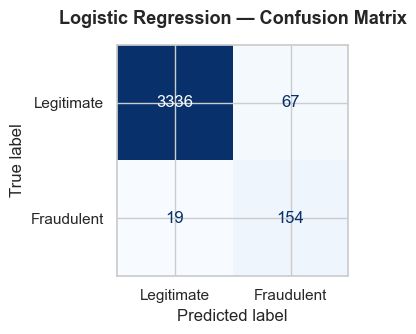

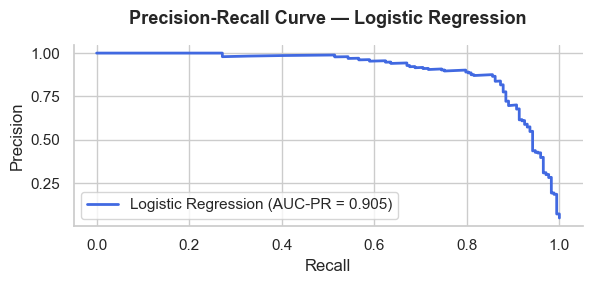


🔍 Confusion Matrix Breakdown:
   True Positives  (fraud caught):    154
   False Negatives (fraud missed):    19
   False Positives (legit flagged):   67
   True Negatives  (legit cleared):   3,336


In [4]:
# Train model
print(f'🤖 Training Logistic Regression baseline...')
lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42)
lr.fit(X_train_sm, y_train_sm)
print(f'✅ Training complete')

# Predict on test set
y_pred_lr = lr.predict(X_test_final)
y_proba_lr = lr.predict_proba(X_test_final)[:, 1]

# Metrics
f1_lr = f1_score(y_test, y_pred_lr)
auc_roc_lr = roc_auc_score(y_test, y_proba_lr)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)
auc_pr_lr = auc(recall_lr, precision_lr)

print(f'\n📈 Logistic Regression — Test Set Performance:')
print(f'   F1 Score:         {f1_lr:.3f}')
print(f'   AUC-ROC:          {auc_roc_lr:.3f}')
print(f'   AUC-PR:           {auc_pr_lr:.3f}')
print(f'\n📋 Classification Report:')
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=[
            'Legitimate',
            'Fraudulent']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 3.5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                              display_labels=['Legitimate', 'Fraudulent'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=13,
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Precision-Recall curve
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(recall_lr, precision_lr, color=PALETTE[0], lw=2,
        label=f'Logistic Regression (AUC-PR = {auc_pr_lr:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Logistic Regression',
             fontsize=13, fontweight='bold', pad=15)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('lr_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🔍 Confusion Matrix Breakdown:')
print(f'   True Positives  (fraud caught):    {cm_lr[1,1]:,}')
print(f'   False Negatives (fraud missed):    {cm_lr[1,0]:,}')
print(f'   False Positives (legit flagged):   {cm_lr[0,1]:,}')
print(f'   True Negatives  (legit cleared):   {cm_lr[0,0]:,}')

## **Step 4 - Random Forest Primary Model**

🌲 Training Random Forest primary model...
✅ Training complete

📈 Random Forest — Test Set Performance:
   F1 Score:         0.774
   AUC-ROC:          0.992
   AUC-PR:           0.924

📋 Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99      3403
  Fraudulent       0.97      0.64      0.77       173

    accuracy                           0.98      3576
   macro avg       0.98      0.82      0.88      3576
weighted avg       0.98      0.98      0.98      3576



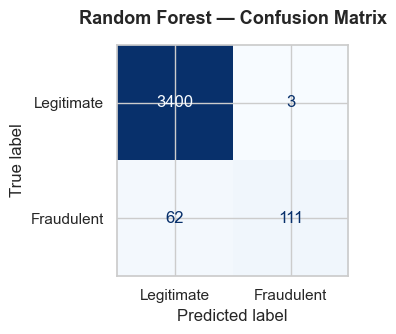

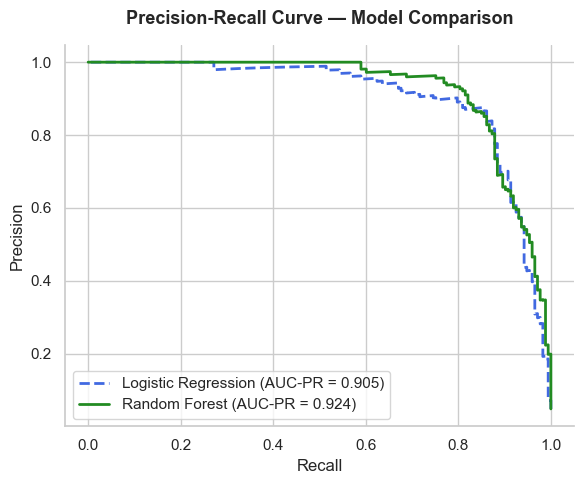


🔍 Confusion Matrix Breakdown:
   True Positives  (fraud caught):    111
   False Negatives (fraud missed):    62
   False Positives (legit flagged):   3
   True Negatives  (legit cleared):   3,400

📊 Model Comparison Summary:
Metric                  Log Reg  Rand Forest
--------------------------------------------
F1 Score                  0.782        0.774
AUC-ROC                   0.987        0.992
AUC-PR                    0.905        0.924


In [5]:
3  # Train model
print(f'🌲 Training Random Forest primary model...')
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)
print(f'✅ Training complete')

# Predict on test set
y_pred_rf = rf.predict(X_test_final)
y_proba_rf = rf.predict_proba(X_test_final)[:, 1]

# Metrics
f1_rf = f1_score(y_test, y_pred_rf)
auc_roc_rf = roc_auc_score(y_test, y_proba_rf)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
auc_pr_rf = auc(recall_rf, precision_rf)

print(f'\n📈 Random Forest — Test Set Performance:')
print(f'   F1 Score:         {f1_rf:.3f}')
print(f'   AUC-ROC:          {auc_roc_rf:.3f}')
print(f'   AUC-PR:           {auc_pr_rf:.3f}')
print(f'\n📋 Classification Report:')
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            'Legitimate',
            'Fraudulent']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 3.5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                              display_labels=['Legitimate', 'Fraudulent'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix', fontsize=13,
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Precision-Recall curve overlaid with LR for comparison
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_lr, precision_lr, color=PALETTE[0], lw=2, linestyle='--',
        label=f'Logistic Regression (AUC-PR = {auc_pr_lr:.3f})')
ax.plot(recall_rf, precision_rf, color=PALETTE[2], lw=2,
        label=f'Random Forest (AUC-PR = {auc_pr_rf:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Model Comparison',
             fontsize=13, fontweight='bold', pad=15)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('rf_pr_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix breakdown
print(f'\n🔍 Confusion Matrix Breakdown:')
print(f'   True Positives  (fraud caught):    {cm_rf[1,1]:,}')
print(f'   False Negatives (fraud missed):    {cm_rf[1,0]:,}')
print(f'   False Positives (legit flagged):   {cm_rf[0,1]:,}')
print(f'   True Negatives  (legit cleared):   {cm_rf[0,0]:,}')

# Model comparison summary
print(f'\n📊 Model Comparison Summary:')
print(f'{"Metric":<20} {"Log Reg":>10} {"Rand Forest":>12}')
print(f'{"-"*44}')
print(f'{"F1 Score":<20} {f1_lr:>10.3f} {f1_rf:>12.3f}')
print(f'{"AUC-ROC":<20} {auc_roc_lr:>10.3f} {auc_roc_rf:>12.3f}')
print(f'{"AUC-PR":<20} {auc_pr_lr:>10.3f} {auc_pr_rf:>12.3f}')

## **Step 5 - Feature Importance**

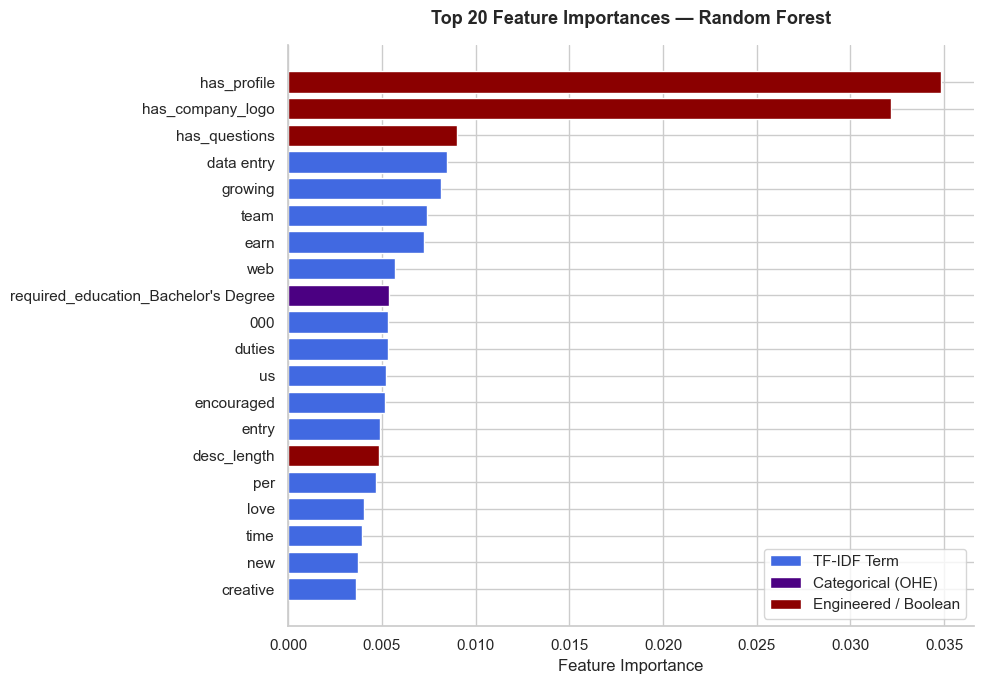

In [6]:
# Get TF-IDF feature names
tfidf_names = tfidf.get_feature_names_out().tolist()

# Get OHE feature names
ohe_names = ohe.get_feature_names_out(CAT_FEATURES).tolist()

# Combine all feature names in the same order as the stacked matrix
all_feature_names = tfidf_names + ohe_names + BOOL_FEATURES + NUM_FEATURES

# Build importance dataframe
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 7))
top20 = importance_df.head(20)
colors = [PALETTE[3] if f in BOOL_FEATURES + NUM_FEATURES
          else PALETTE[1] if any(f.startswith(c) for c in CAT_FEATURES)
          else PALETTE[0]
          for f in top20['feature']]
ax.barh(top20['feature'][::-1], top20['importance'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 20 Feature Importances — Random Forest',
             fontsize=13, fontweight='bold', pad=15)

# Legend
legend_elements = [
    Patch(facecolor=PALETTE[0], label='TF-IDF Term'),
    Patch(facecolor=PALETTE[1], label='Categorical (OHE)'),
    Patch(facecolor=PALETTE[3], label='Engineered / Boolean')
]
ax.legend(handles=legend_elements, loc='lower right')
sns.despine()
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="border: 5px solid green; border-radius: 8px; padding: 20px;">

# Reflection 

## Overall Reflection
Milestone 4 represented the point in the project where most of the technical work came together, and it allowed me to evaluate the effectiveness of the modeling pipeline I developed in earlier stages. This milestone required a complete data preparation workflow, model development, evaluation, and the beginning of actionable recommendations. 

My process included handling missing values, engineering both structured and text-based features, addressing class imbalance, and comparing multiple classification models. I evaluated Logistic Regression and Random Forest using metrics appropriate for fraud detection, including precision, recall, F1-score, AUC-ROC, AUC-PR, and confusion matrices. Logistic Regression ultimately emerged as the preferred model due to its stronger recall for fraudulent postings, which aligns with the practical need to minimize missed fraud cases. 

Overall, this milestone strengthened my understanding of how preprocessing decisions, model selection, and evaluation metrics interact in a real-world predictive analytics workflow. It also clarified how model performance should be interpreted in the context of business risk and operational constraints.

---

## Straightforward Aspects
Several components of Milestone 4 aligned closely with techniques I have used in previous courses, making them relatively straightforward:

- **Data preparation and cleaning** followed a familiar pattern: removing missing values, encoding categorical variables, and constructing engineered features. The workflow felt natural and consistent with earlier milestones.
- **Model training and evaluation** using scikit-learn pipelines was intuitive. The pipeline structure made it easy to standardize preprocessing and ensure consistent transformations across models.
- **Comparing Logistic Regression and Random Forest** was also direct. Both models behaved as expected: Logistic Regression provided more stable recall, while Random Forest offered higher precision but at the cost of missing more fraudulent cases.
- **Interpreting evaluation metrics** such as precision, recall, F1, and ROC/PR curves felt comfortable, especially given the fraud-detection framing where recall is often prioritized.

These elements made the modeling process smooth and allowed me to focus more deeply on the nuances of model behavior rather than the mechanics of implementation.

---

## Challenging Aspects
While the overall workflow was manageable, several aspects required more careful thought and presented meaningful challenges:

- **Ensuring consistency between the written description and the code** was more difficult than expected. For example, I realized that `has_salary` was created after dropping `salary_range`, which caused the feature to default to 0 rather than reflect the original data. This highlighted the importance of verifying that narrative explanations match the actual code execution.
- **Handling class imbalance effectively** required more than simply avoiding accuracy. Choosing the right metrics and interpreting them in context—especially the tradeoff between recall and precision—was a deeper conceptual challenge. It reinforced how different models optimize different aspects of performance.
- **Evaluating models using multiple metrics** introduced complexity. For fraud detection, recall is critical, but high recall can increase false positives and operational workload. Balancing these competing priorities required more nuanced reasoning than simply selecting the model with the highest score.
- **Considering threshold tuning** for Logistic Regression emerged as an important next step. The default 0.5 threshold may not reflect the optimal balance between catching fraud and minimizing unnecessary manual review. This added an additional layer of decision-making that goes beyond standard model evaluation.
- **Managing text preprocessing** and ensuring it was both effective and reproducible required attention to detail. Even small inconsistencies between described and implemented steps can affect downstream model performance.

These challenges ultimately strengthened my understanding of how predictive analytics projects evolve and how small decisions in preprocessing or evaluation can meaningfully influence final recommendations.

---

## Conclusion
Milestone 4 brought together data preparation, modeling, evaluation, and early recommendations into a cohesive workflow. The experience reinforced the importance of aligning model performance with real-world risk considerations, especially in fraud detection where missing positive cases carries significant consequences. Moving into the final milestone, I plan to refine the feature engineering steps, correct the `has_salary` issue, ensure full alignment between code and narrative, and explore threshold tuning to better balance recall and precision in the final model.

</div>